# 02 GNN Training

This notebook trains a 2-layer GraphSAGE GNN on the EU AI Act graph using the same artifacts and workflow style as `02_gcn_training.ipynb`, while saving separate GNN outputs for comparison.


## Hyperparameter choice and justification

This notebook mirrors the GCN notebook workflow but swaps the encoder to GraphSAGE (`SAGEConv`).

Chosen settings:
- `num_layers = 2`: shallow message passing is a safe default for legal graphs and limits oversmoothing risk.
- `hidden_channels = 768`: fixed to match the requested wider hidden representation.
- `out_channels = 768`: keeps output width aligned with retrieval embedding dimensionality.
- `dropout = 0.5`: regularization used consistently with the GCN training setup.
- `learning_rate = 5e-4` and `weight_decay = 1e-3`: taken from project training config for stable contrastive optimization.
- `temperature = 0.07`, `num_negatives = 3`: same InfoNCE setup family as the GCN notebook for fair comparison.

Reference:
- Hamilton et al., *Inductive Representation Learning on Large Graphs* (GraphSAGE): https://arxiv.org/abs/1706.02216
- PyTorch Geometric `SAGEConv` docs: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.SAGEConv.html


In [26]:
import random
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import degree

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'configs').exists() and (REPO_ROOT / '..' / 'configs').exists():
    REPO_ROOT = (REPO_ROOT / '..').resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def load_config(config_path: str = 'configs/config.yaml') -> dict:
    with open(config_path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _resolve_path(*candidates):
    for candidate in candidates:
        if not candidate:
            continue
        p = Path(candidate)
        if p.is_absolute() and p.exists():
            return p
        local = REPO_ROOT / p
        if local.exists():
            return local
        parent = (REPO_ROOT / '..' / p).resolve()
        if parent.exists():
            return parent
    return None


config = load_config(str(_resolve_path('configs/config.yaml', '../configs/config.yaml')))
set_seed(config['project']['seed'])

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')

Device: mps


In [27]:
def _normalize_node_metadata(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'kind' in df.columns and 'type' not in df.columns:
        df = df.rename(columns={'kind': 'type'})
    elif 'node_type' in df.columns and 'type' not in df.columns:
        df = df.rename(columns={'node_type': 'type'})
    if 'type' not in df.columns:
        df['type'] = 'unknown'
    df['type'] = df['type'].fillna('unknown').astype(str).str.lower()
    if 'node_id' not in df.columns and 'id' in df.columns:
        df = df.rename(columns={'id': 'node_id'})
    if 'node_id' not in df.columns:
        df['node_id'] = [f'node_{i}' for i in range(len(df))]
    if 'title' not in df.columns:
        df['title'] = ''
    df['title'] = df['title'].fillna('').astype(str)
    if 'text' in df.columns:
        missing_title = df['title'].str.strip() == ''
        df.loc[missing_title, 'title'] = df.loc[missing_title, 'text'].fillna('').astype(str).str[:120]
    return df


graph_path = _resolve_path(config['paths']['graph_object'], Path('..') / config['paths']['graph_object'])
nodes_path = _resolve_path(config['paths']['nodes_csv'], Path('..') / config['paths']['nodes_csv'])
edges_path = _resolve_path(config['paths']['edges_csv'], Path('..') / config['paths']['edges_csv'])

if None in [graph_path, nodes_path, edges_path]:
    raise FileNotFoundError('Could not resolve graph/nodes/edges paths from config')

data = torch.load(graph_path, weights_only=False)
nodes_df = _normalize_node_metadata(pd.read_csv(nodes_path))
edges_df = pd.read_csv(edges_path)

node_features_path = _resolve_path(config['paths']['node_features'], Path('..') / config['paths']['node_features'])
if node_features_path is None:
    raise FileNotFoundError('Could not resolve node_features.npy path from config')

node_features = np.load(node_features_path).astype(np.float32)
if node_features.shape[0] != data.num_nodes:
    n = min(node_features.shape[0], data.num_nodes)
    node_features = node_features[:n]
    if len(nodes_df) != n:
        nodes_df = nodes_df.iloc[:n].reset_index(drop=True)
    mask = (data.edge_index[0] < n) & (data.edge_index[1] < n)
    data.edge_index = data.edge_index[:, mask]
    if hasattr(data, 'edge_type'):
        data.edge_type = data.edge_type[mask]
    data.num_nodes = n

data.x = torch.from_numpy(node_features)

if len(nodes_df) != data.num_nodes:
    n = min(len(nodes_df), data.num_nodes)
    nodes_df = nodes_df.iloc[:n].reset_index(drop=True)
    if data.x.size(0) != n:
        data.x = data.x[:n]
    mask = (data.edge_index[0] < n) & (data.edge_index[1] < n)
    data.edge_index = data.edge_index[:, mask]
    if hasattr(data, 'edge_type'):
        data.edge_type = data.edge_type[mask]
    data.num_nodes = n

print(f'Graph path:     {graph_path}')
print(f'Nodes path:     {nodes_path}')
print(f'Edges path:     {edges_path}')
print(f'Node features:  {node_features_path}')
print(f'Nodes:          {data.num_nodes}')
print(f'Edges:          {data.edge_index.size(1)}')
print(f'Feature shape (from node_features.npy):  {tuple(data.x.shape)}')
print(f'Node types:     {nodes_df["type"].value_counts().to_dict()}')

Graph path:     /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/data/graphs/eu_ai_act_graph.pt
Nodes path:     /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/data/processed/nodes.csv
Edges path:     /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/data/processed/edges.csv
Nodes:          974
Edges:          3873
Feature shape:  (974, 391)
Node types:     {'paragraph': 500, 'recital': 180, 'article': 115, 'annex_item': 100, 'definition': 66, 'annex': 13}


In [28]:
def split_edges(edge_index: torch.Tensor, train_ratio: float = 0.8, val_ratio: float = 0.2) -> dict:
    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)
    train_end = int(num_edges * train_ratio)
    val_end = int(num_edges * (train_ratio + val_ratio))
    return {
        'train': edge_index[:, perm[:train_end]],
        'val': edge_index[:, perm[train_end:val_end]],
    }


def build_forbid_adjacency(edge_index: torch.Tensor, num_nodes: int) -> list[set[int]]:
    adj = [set() for _ in range(num_nodes)]
    for src, dst in edge_index.t().tolist():
        if 0 <= src < num_nodes and 0 <= dst < num_nodes:
            adj[src].add(dst)
            adj[dst].add(src)
    return adj


def sample_contrastive_pairs(edge_index: torch.Tensor, num_nodes: int, num_negatives: int, forbid_adj: Optional[list[set[int]]] = None):
    anchors = edge_index[0]
    positives = edge_index[1]
    negatives = torch.empty((anchors.size(0), num_negatives), dtype=torch.long)
    if forbid_adj is None:
        forbid_adj = [set() for _ in range(num_nodes)]

    for i in range(anchors.size(0)):
        a = int(anchors[i].item())
        forbidden = set(forbid_adj[a]) if a < len(forbid_adj) else set()
        forbidden.add(a)
        for j in range(num_negatives):
            neg = torch.randint(0, num_nodes, (1,)).item()
            tries = 0
            while neg in forbidden and tries < 50:
                neg = torch.randint(0, num_nodes, (1,)).item()
                tries += 1
            negatives[i, j] = neg
    return anchors, positives, negatives


def infonce_loss(anchor_emb: torch.Tensor, positive_emb: torch.Tensor, negative_embs: torch.Tensor, temperature: float = 0.07) -> torch.Tensor:
    pos_sim = F.cosine_similarity(anchor_emb, positive_emb, dim=-1) / temperature
    neg_sim = F.cosine_similarity(anchor_emb.unsqueeze(1), negative_embs, dim=-1) / temperature
    logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
    labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
    return F.cross_entropy(logits, labels)


def evaluate_split(model: nn.Module, x: torch.Tensor, train_edge_index: torch.Tensor, split_edge_index: torch.Tensor, num_nodes: int, num_negatives: int, temperature: float, forbid_adj: list[set[int]]) -> float:
    model.eval()
    with torch.no_grad():
        embeddings = model(x, train_edge_index)
        a, p, n = sample_contrastive_pairs(split_edge_index.cpu(), num_nodes, num_negatives, forbid_adj)
        a = a.to(x.device)
        p = p.to(x.device)
        n = n.to(x.device)
        loss = infonce_loss(embeddings[a], embeddings[p], embeddings[n], temperature)
    return float(loss.item())

In [ ]:
class GNNEncoder(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int = 768, out_channels: int = 768, dropout: float = 0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, normalize=True)
        self.conv2 = SAGEConv(hidden_channels, out_channels, normalize=True)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.normalize(x, p=2, dim=-1)


GNN_HPARAMS = {
    'hidden_channels': config['gnn'].get('hidden_channels', 768),
    'out_channels': config['gnn'].get('out_channels', 768),
    'dropout': config['gnn'].get('dropout', 0.5),
    'epochs': config['training'].get('epochs', 200),
    'learning_rate': config['training'].get('learning_rate', 5e-4),
    'weight_decay': config['training'].get('weight_decay', 1e-3),
    'patience': config['training'].get('patience', 8),
    'num_negatives': config['training'].get('num_negatives', 3),
    'temperature': config['training'].get('temperature', 0.07),
    'scheduler': 'cosine',
}

print('GNN hyperparameters:')
for k, v in GNN_HPARAMS.items():
    print(f'  {k:16}: {v}')


GNN hyperparameters:
  hidden_channels : 768
  out_channels    : 768
  dropout         : 0.5
  epochs          : 200
  learning_rate   : 0.0005
  weight_decay    : 0.001
  patience        : 8
  num_negatives   : 3
  temperature     : 0.07
  scheduler       : cosine


In [30]:
edge_splits = split_edges(
    data.edge_index,
    train_ratio=config['training']['train_ratio'],
    val_ratio=config['training']['val_ratio'],
)
forbid_adj = build_forbid_adjacency(data.edge_index.cpu(), data.num_nodes)

x = data.x.to(device)
train_edge_index = edge_splits['train'].to(device)
val_edge_index = edge_splits['val']

ckpt_path = REPO_ROOT / 'models' / 'checkpoints' / 'gnn_best.pt'
emb_path = REPO_ROOT / 'models' / 'embeddings' / 'gnn_node_embeddings.npy'
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
emb_path.parent.mkdir(parents=True, exist_ok=True)

ENABLE_RANDOM_SEARCH = True
RANDOM_SEARCH_TRIALS = 20


def run_hparam_trial(hparams: dict) -> float:
    trial_model = GNNEncoder(
        in_channels=data.x.size(1),
        hidden_channels=hparams['hidden_channels'],
        out_channels=hparams['out_channels'],
        dropout=hparams['dropout'],
    ).to(device)
    trial_optimizer = Adam(
        trial_model.parameters(),
        lr=hparams['learning_rate'],
        weight_decay=hparams['weight_decay'],
    )
    trial_scheduler = CosineAnnealingLR(trial_optimizer, T_max=hparams['epochs'])

    best_trial_val = float('inf')
    patience_counter = 0

    for epoch in range(1, hparams['epochs'] + 1):
        trial_model.train()
        embeddings = trial_model(x, train_edge_index)
        a, p, n = sample_contrastive_pairs(
            edge_splits['train'].cpu(),
            data.num_nodes,
            hparams['num_negatives'],
            forbid_adj,
        )
        a = a.to(device)
        p = p.to(device)
        n = n.to(device)

        loss = infonce_loss(embeddings[a], embeddings[p], embeddings[n], hparams['temperature'])

        trial_optimizer.zero_grad()
        loss.backward()
        trial_optimizer.step()
        trial_scheduler.step()

        val_loss = evaluate_split(
            trial_model,
            x,
            train_edge_index,
            val_edge_index,
            data.num_nodes,
            hparams['num_negatives'],
            hparams['temperature'],
            forbid_adj,
        )

        if val_loss < best_trial_val:
            best_trial_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= hparams['patience']:
            break

    return float(best_trial_val)


if ENABLE_RANDOM_SEARCH and RANDOM_SEARCH_TRIALS > 0:
    search_space = {
        'hidden_channels': sorted(set([max(32, GNN_HPARAMS['hidden_channels'] // 2), GNN_HPARAMS['hidden_channels'], GNN_HPARAMS['hidden_channels'] * 2])),
        'dropout': [0.2, 0.3, 0.5, 0.6],
        'learning_rate': [3e-4, 5e-4, 1e-3, 2e-3, 5e-3],
        'weight_decay': [1e-5, 1e-4, 5e-4, 1e-3, 5e-3],
        'num_negatives': [2, 3, 5, 8],
        'temperature': [0.03, 0.05, 0.07, 0.1, 0.15],
    }

    print(f'Running random search for GNN hyperparameters ({RANDOM_SEARCH_TRIALS} trials)...')

    best_trial = None
    random_search_rows = []

    for trial_idx in range(1, RANDOM_SEARCH_TRIALS + 1):
        sampled = dict(GNN_HPARAMS)
        sampled['hidden_channels'] = int(random.choice(search_space['hidden_channels']))
        sampled['dropout'] = float(random.choice(search_space['dropout']))
        sampled['learning_rate'] = float(random.choice(search_space['learning_rate']))
        sampled['weight_decay'] = float(random.choice(search_space['weight_decay']))
        sampled['num_negatives'] = int(random.choice(search_space['num_negatives']))
        sampled['temperature'] = float(random.choice(search_space['temperature']))

        trial_val = run_hparam_trial(sampled)

        row = dict(sampled)
        row['trial'] = trial_idx
        row['best_val_loss'] = trial_val
        random_search_rows.append(row)

        if best_trial is None or trial_val < best_trial['best_val_loss']:
            best_trial = row

        print(
            f"Trial {trial_idx:02d} | val={trial_val:.4f} | "
            f"hidden={sampled['hidden_channels']} dropout={sampled['dropout']} "
            f"lr={sampled['learning_rate']} wd={sampled['weight_decay']} "
            f"neg={sampled['num_negatives']} temp={sampled['temperature']}"
        )

    random_search_df = pd.DataFrame(random_search_rows).sort_values('best_val_loss').reset_index(drop=True)
    display(random_search_df.head(min(10, len(random_search_df))))

    best_hparams = dict(GNN_HPARAMS)
    for key in ['hidden_channels', 'dropout', 'learning_rate', 'weight_decay', 'num_negatives', 'temperature']:
        best_hparams[key] = best_trial[key]
    GNN_HPARAMS = best_hparams

    print('Selected best random-search hyperparameters:')
    for k, v in GNN_HPARAMS.items():
        print(f'  {k:16}: {v}')

model = GNNEncoder(
    in_channels=data.x.size(1),
    hidden_channels=GNN_HPARAMS['hidden_channels'],
    out_channels=GNN_HPARAMS['out_channels'],
    dropout=GNN_HPARAMS['dropout'],
).to(device)
optimizer = Adam(model.parameters(), lr=GNN_HPARAMS['learning_rate'], weight_decay=GNN_HPARAMS['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=GNN_HPARAMS['epochs'])

print(f'Train edges: {edge_splits["train"].size(1)}')
print(f'Val edges:   {edge_splits["val"].size(1)}')
print(f'Parameters:  {sum(p.numel() for p in model.parameters()):,}')
print(model)


Running random search for GNN hyperparameters (20 trials)...
Trial 01 | val=0.2838 | hidden=1536 dropout=0.2 lr=0.0003 wd=0.0005 neg=3 temp=0.05
Trial 02 | val=0.5831 | hidden=384 dropout=0.2 lr=0.005 wd=1e-05 neg=8 temp=0.03
Trial 03 | val=0.2644 | hidden=384 dropout=0.2 lr=0.0005 wd=0.0001 neg=2 temp=0.15
Trial 04 | val=0.3428 | hidden=384 dropout=0.6 lr=0.0005 wd=0.001 neg=5 temp=0.03
Trial 05 | val=0.2066 | hidden=384 dropout=0.6 lr=0.001 wd=0.0005 neg=3 temp=0.05
Trial 06 | val=0.1588 | hidden=768 dropout=0.2 lr=0.0003 wd=0.001 neg=2 temp=0.07
Trial 07 | val=0.1983 | hidden=768 dropout=0.5 lr=0.0003 wd=0.001 neg=2 temp=0.1
Trial 08 | val=0.3450 | hidden=384 dropout=0.5 lr=0.005 wd=0.0005 neg=3 temp=0.03
Trial 09 | val=0.1786 | hidden=384 dropout=0.3 lr=0.001 wd=1e-05 neg=3 temp=0.03
Trial 10 | val=0.2529 | hidden=768 dropout=0.5 lr=0.002 wd=0.0005 neg=3 temp=0.07
Trial 11 | val=0.3212 | hidden=768 dropout=0.3 lr=0.001 wd=1e-05 neg=3 temp=0.15
Trial 12 | val=0.4317 | hidden=1536 dr

,hidden_channels,out_channels,dropout,epochs,learning_rate,weight_decay,patience,num_negatives,temperature,scheduler,trial,best_val_loss
0,768,768,0.2,200,0.0003,0.00100,8,2,0.07,cosine,6,0.158833
1,768,768,0.2,200,0.0003,0.00001,8,3,0.05,cosine,18,0.161850
2,384,768,0.3,200,0.0010,0.00001,8,3,0.03,cosine,9,0.178621
3,768,768,0.5,200,0.0003,0.00100,8,2,0.10,cosine,7,0.198349
4,384,768,0.6,200,0.0010,0.00050,8,3,0.05,cosine,5,0.206590
5,1536,768,0.3,200,0.0010,0.00001,8,3,0.03,cosine,13,0.214696
6,768,768,0.5,200,0.0020,0.00050,8,3,0.07,cosine,10,0.252876
7,384,768,0.2,200,0.0005,0.00010,8,2,0.15,cosine,3,0.264422
8,1536,768,0.2,200,0.0003,0.00050,8,3,0.05,cosine,1,0.283830
9,768,768,0.3,200,0.0010,0.00001,8,3,0.15,cosine,11,0.321229


Selected best random-search hyperparameters:
  hidden_channels : 768
  out_channels    : 768
  dropout         : 0.2
  epochs          : 200
  learning_rate   : 0.0003
  weight_decay    : 0.001
  patience        : 8
  num_negatives   : 2
  temperature     : 0.07
  scheduler       : cosine
Train edges: 3098
Val edges:   775
Parameters:  1,781,760
GNNEncoder(
  (conv1): SAGEConv(391, 768, aggr=mean)
  (conv2): SAGEConv(768, 768, aggr=mean)
)


In [31]:
train_losses = []
val_losses = []
lr_history = []
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0

for epoch in range(1, GNN_HPARAMS['epochs'] + 1):
    model.train()
    embeddings = model(x, train_edge_index)
    a, p, n = sample_contrastive_pairs(edge_splits['train'].cpu(), data.num_nodes, GNN_HPARAMS['num_negatives'], forbid_adj)
    a = a.to(device)
    p = p.to(device)
    n = n.to(device)
    loss = infonce_loss(embeddings[a], embeddings[p], embeddings[n], GNN_HPARAMS['temperature'])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    val_loss = evaluate_split(
        model,
        x,
        train_edge_index,
        val_edge_index,
        data.num_nodes,
        GNN_HPARAMS['num_negatives'],
        GNN_HPARAMS['temperature'],
        forbid_adj,
    )

    train_losses.append(float(loss.item()))
    val_losses.append(val_loss)
    lr_history.append(float(optimizer.param_groups[0]['lr']))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        marker = ' <- best' if epoch == best_epoch else ''
        print(f'Epoch {epoch:4d}/{GNN_HPARAMS["epochs"]} | Train {loss.item():.4f} | Val {val_loss:.4f} | LR {optimizer.param_groups[0]["lr"]:.6f}{marker}')

    if patience_counter >= GNN_HPARAMS['patience']:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'Best val loss: {best_val_loss:.4f} at epoch {best_epoch}')
print(f'Checkpoint: {ckpt_path}')

Epoch    1/200 | Train 0.9581 | Val 0.9573 | LR 0.000300 <- best
Epoch   10/200 | Train 0.2934 | Val 0.4263 | LR 0.000298 <- best
Epoch   20/200 | Train 0.1670 | Val 0.3029 | LR 0.000293 <- best
Epoch   30/200 | Train 0.1351 | Val 0.2090 | LR 0.000284
Early stopping at epoch 37
Best val loss: 0.1989 at epoch 29
Checkpoint: /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/models/checkpoints/gnn_best.pt


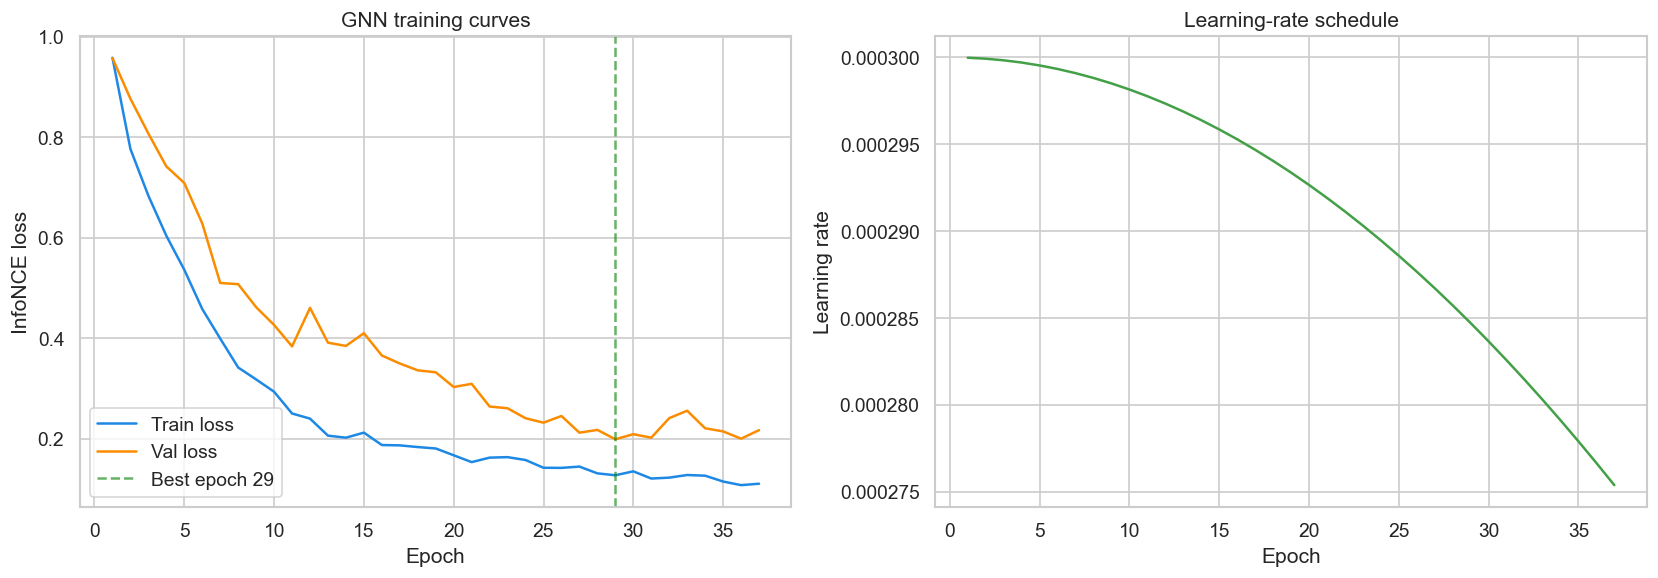

Validation-only protocol: final model selection is based on the best validation loss above.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='Train loss', color='#1E88E5')
axes[0].plot(epochs_range, val_losses, label='Val loss', color='#FB8C00')
axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.6, label=f'Best epoch {best_epoch}')
axes[0].set_title('GNN training curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('InfoNCE loss')
axes[0].legend()

axes[1].plot(epochs_range, lr_history, color='#43A047')
axes[1].set_title('Learning-rate schedule')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning rate')

plt.tight_layout()
plt.show()

print('Validation-only protocol: final model selection is based on the best validation loss above.')

In [33]:
best_state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    gnn_embeddings = model(data.x.to(device), data.edge_index.to(device)).cpu().numpy()

np.save(emb_path, gnn_embeddings)
print(f'Saved embeddings: {emb_path}')
print(f'Embedding shape:  {gnn_embeddings.shape}')
print(f'Mean L2 norm:     {np.linalg.norm(gnn_embeddings, axis=1).mean():.4f}')

/var/folders/5c/tdddtgcj407b56jk_hth05gh0000gn/T/ipykernel_90222/1963346822.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_state = torch.load(ckpt_path, map_locati

Saved embeddings: /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/models/embeddings/gnn_node_embeddings.npy
Embedding shape:  (974, 768)
Mean L2 norm:     1.0000


In [34]:
print('Running 3D t-SNE...')
perp = min(30, max(2, len(gnn_embeddings) - 1))
emb_3d = TSNE(n_components=3, perplexity=perp, random_state=42, max_iter=1000).fit_transform(gnn_embeddings)

color_map = {
    'article': '#E53935',
    'paragraph': '#1E88E5',
    'recital': '#43A047',
    'definition': '#FB8C00',
    'annex': '#8E24AA',
    'annex_item': '#00ACC1',
}

plot_df = nodes_df.copy().reset_index(drop=True)
plot_df['tsne_1'] = emb_3d[:, 0]
plot_df['tsne_2'] = emb_3d[:, 1]
plot_df['tsne_3'] = emb_3d[:, 2]
plot_df['type'] = plot_df['type'].astype(str)
plot_df['node_id'] = plot_df['node_id'].astype(str)
plot_df['hover_text'] = plot_df['text'].fillna('').astype(str).str.slice(0, 220)

fig = px.scatter_3d(
    plot_df,
    x='tsne_1',
    y='tsne_2',
    z='tsne_3',
    color='type',
    color_discrete_map=color_map,
    hover_name='node_id',
    hover_data={
        'type': True,
        'hover_text': True,
        'tsne_1': ':.3f',
        'tsne_2': ':.3f',
        'tsne_3': ':.3f',
    },
    title='GNN embeddings 3D t-SNE by node type',
    width=1000,
    height=750,
)
fig.update_traces(marker=dict(size=4, opacity=0.75))
fig.update_layout(
    legend_title_text='Node type',
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3',
    ),
)
fig.show()

Running 3D t-SNE...


In [35]:
def find_nearest_neighbours(query_node_id, embeddings, nodes_df, top_k=10):
    node_ids = nodes_df['node_id'].astype(str).values
    query = str(query_node_id)
    query_norm = query.replace('_', ' ').lower()

    candidates = [i for i, nid in enumerate(node_ids) if str(nid).lower() == query.lower()]
    if not candidates:
        candidates = [i for i, nid in enumerate(node_ids) if query_norm in str(nid).lower().replace('_', ' ')]
    if not candidates:
        raise KeyError(f"Could not find node_id '{query}'")

    idx = candidates[0]
    sims = cosine_similarity(embeddings[idx:idx + 1], embeddings)[0]
    sims[idx] = -1
    top_indices = np.argsort(sims)[::-1][:top_k]

    rows = []
    for rank, i in enumerate(top_indices, start=1):
        row = nodes_df.iloc[int(i)]
        rows.append({
            'rank': rank,
            'node_id': row['node_id'],
            'type': row.get('type', 'unknown'),
            'title': row.get('title', ''),
            'similarity': float(sims[int(i)]),
        })
    return pd.DataFrame(rows)


print('Article 5 neighbours')
display(find_nearest_neighbours('Article 5', gnn_embeddings, nodes_df, top_k=10))

print('Article 6 neighbours')
display(find_nearest_neighbours('Article 6', gnn_embeddings, nodes_df, top_k=10))

Article 5 neighbours


,rank,node_id,type,title,similarity
0,1,article_50,article,Article 50: Transparency obligations for provi...,0.894462
1,2,article_5_para_1,paragraph,"Article 5, Paragraph 1",0.846213
2,3,article_3,article,Article 3: Definitions,0.843809
3,4,definition_46,definition,Definition: law enforcement,0.842600
4,5,definition_1,definition,Definition: AI system,0.837974
5,6,definition_52,definition,Definition: profiling,0.836414
6,7,definition_11,definition,Definition: putting into service,0.832650
7,8,definition_4,definition,Definition: deployer,0.824121
8,9,annex_II,annex,Annex II: List of criminal offences referred t...,0.816464
9,10,definition_2,definition,Definition: risk,0.816219


Article 6 neighbours


,rank,node_id,type,title,similarity
0,1,article_6_para_1,paragraph,"Article 6, Paragraph 1",0.909622
1,2,article_2,article,Article 2: Scope,0.870402
2,3,article_8,article,Article 8: Compliance with the requirements,0.862286
3,4,article_7,article,Article 7: Amendments to Annex III,0.861910
4,5,article_6_para_2,paragraph,"Article 6, Paragraph 2",0.856513
5,6,article_6_para_4,paragraph,"Article 6, Paragraph 4",0.854490
6,7,article_49,article,Article 49: Registration,0.850859
7,8,article_16,article,Article 16: Obligations of providers of high-r...,0.850109
8,9,article_7_para_1,paragraph,"Article 7, Paragraph 1",0.848862
9,10,article_25,article,Article 25: Responsibilities along the AI valu...,0.848002
